In [1]:
import os
import sys

# Allows the notebook to import modules from the src folder
sys.path.append(os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Import reusable project functions
from src.data_loader import load_processed_prices

from src.preprocessing import split_train_test

from src.forecasting import (
    train_arima,
    forecast,
    evaluate
)

from src.forecasting import (
    train_arima,
    forecast,
    evaluate
)

2026-07-07 13:35:28.336351: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#prices = pd.read_csv(
 #   "../data/processed/prices.csv",
  #  index_col=0,
   # parse_dates=True
#)

#prices.head()

prices = load_processed_prices()

prices.head()

,BND,SPY,TSLA
Date,,,
2015-01-02,59.205647,169.687851,14.620667
2015-01-05,59.377579,166.623306,14.006000
2015-01-06,59.549515,165.053909,14.085333
2015-01-07,59.585354,167.110672,14.063333
2015-01-08,59.492188,170.076096,14.041333


In [3]:
tsla = prices["TSLA"].copy()

tsla.head()

Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: TSLA, dtype: float64

Chronological Train/Test Split

In [4]:
#train = tsla.loc[:'2024-12-31']

#test = tsla.loc['2025-01-01':]
train, test = split_train_test(tsla)
print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 2516
Testing observations: 373


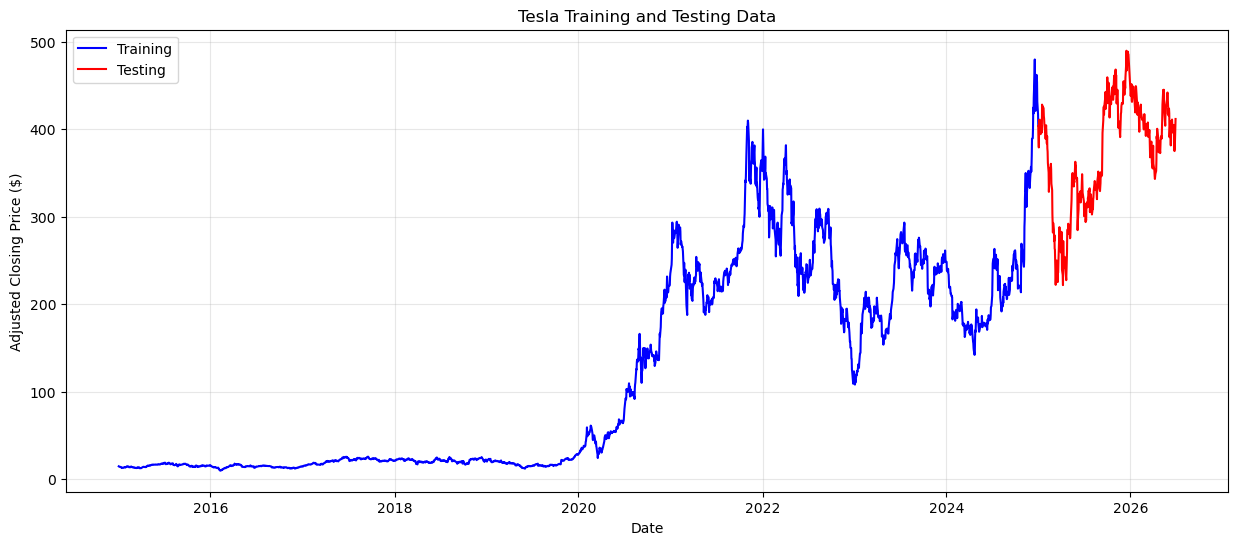

In [5]:
plt.figure(figsize=(15,6))

plt.plot(train,
         label="Training",
         color="blue")

plt.plot(test,
         label="Testing",
         color="red")

plt.title("Tesla Training and Testing Data")

plt.xlabel("Date")

plt.ylabel("Adjusted Closing Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

ARIMA

In [6]:
!pip install pmdarima statsmodels

In [7]:
import sys

!{sys.executable} -m pip install pmdarima

from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

from statsmodels.tsa.arima.model import ARIMA

Visualize ACF and PACF

<Figure size 1400x500 with 0 Axes>

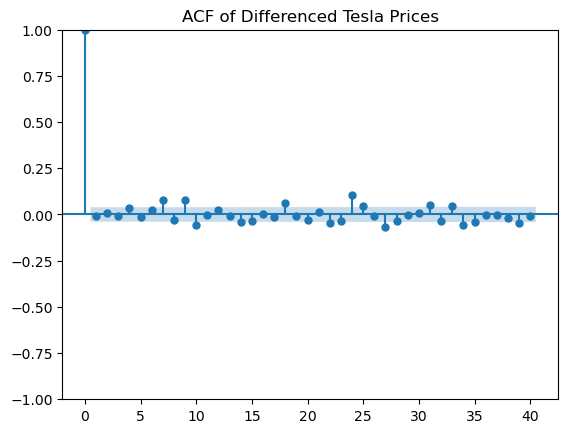

<Figure size 1400x500 with 0 Axes>

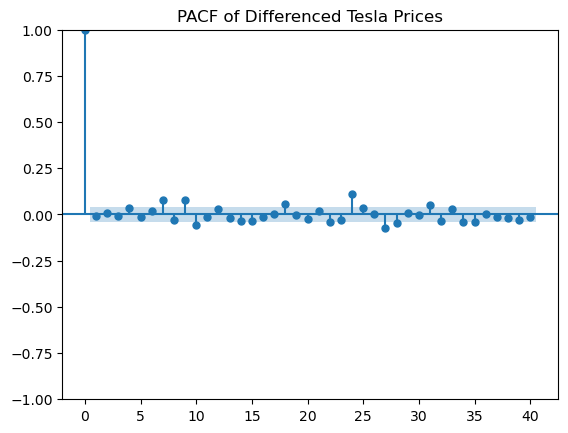

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(14, 5))
plot_acf(train.diff().dropna(), lags=40)
plt.title("ACF of Differenced Tesla Prices")
plt.show()

plt.figure(figsize=(14, 5))
plot_pacf(train.diff().dropna(), lags=40, method="ywm")
plt.title("PACF of Differenced Tesla Prices")
plt.show()

Automatically Find Best ARIMA Parameters

In [9]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=1.74 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.16 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.33 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 8.500 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 07 Jul 2026   AIC                          16368.109
Time:                        13:36:01   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
    

Build the Final ARIMA Model

In [10]:
from statsmodels.tsa.arima.model import ARIMA

#arima_model = ARIMA(
 #   train,
  #  order=(0,1,0)
#)

#arima_fit = arima_model.fit()

arima_fit = train_arima(train)

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Tue, 07 Jul 2026   AIC                          16368.109
Time:                        13:36:01   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Pr

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Generate Forecasts

In [11]:
#forecast_result = arima_fit.get_forecast(
   # steps=len(test)
#)
from src.forecasting import forecast

forecast_values = forecast(
    arima_fit,
    len(test)
)

forecast = forecast_values.predicted_mean

confidence_intervals = forecast_values.conf_int()

forecast.head()

/opt/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


2516    403.839996
2517    403.839996
2518    403.839996
2519    403.839996
2520    403.839996
Name: predicted_mean, dtype: float64

Plot Predictions

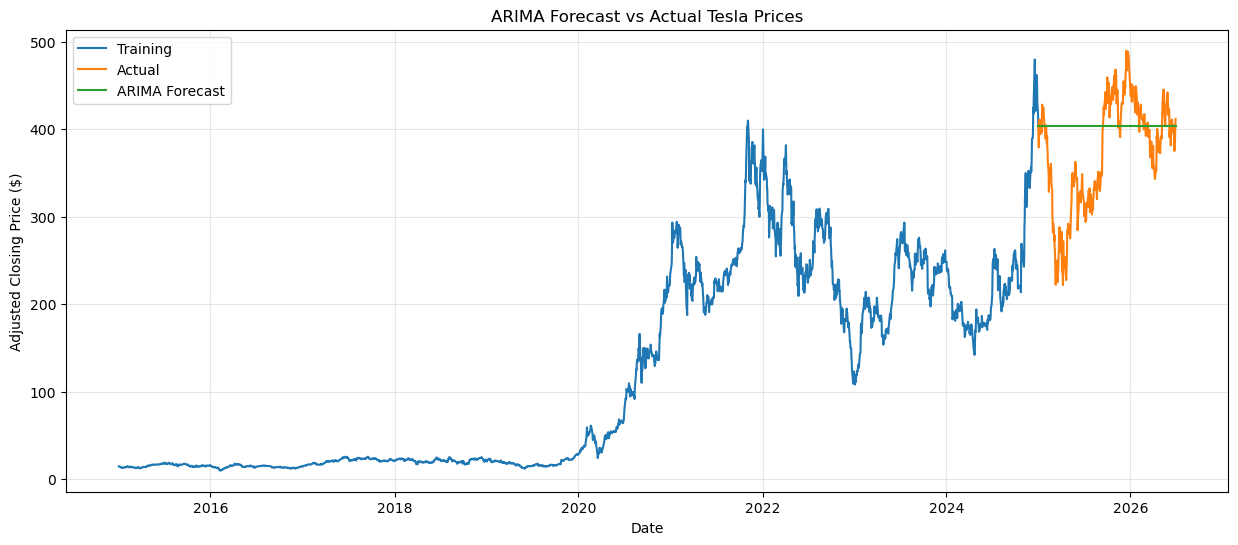

In [12]:
plt.figure(figsize=(15,6))

plt.plot(train,
         label="Training")

plt.plot(test,
         label="Actual")

plt.plot(test.index,
         forecast,
         label="ARIMA Forecast")

plt.title("ARIMA Forecast vs Actual Tesla Prices")

plt.xlabel("Date")

plt.ylabel("Adjusted Closing Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

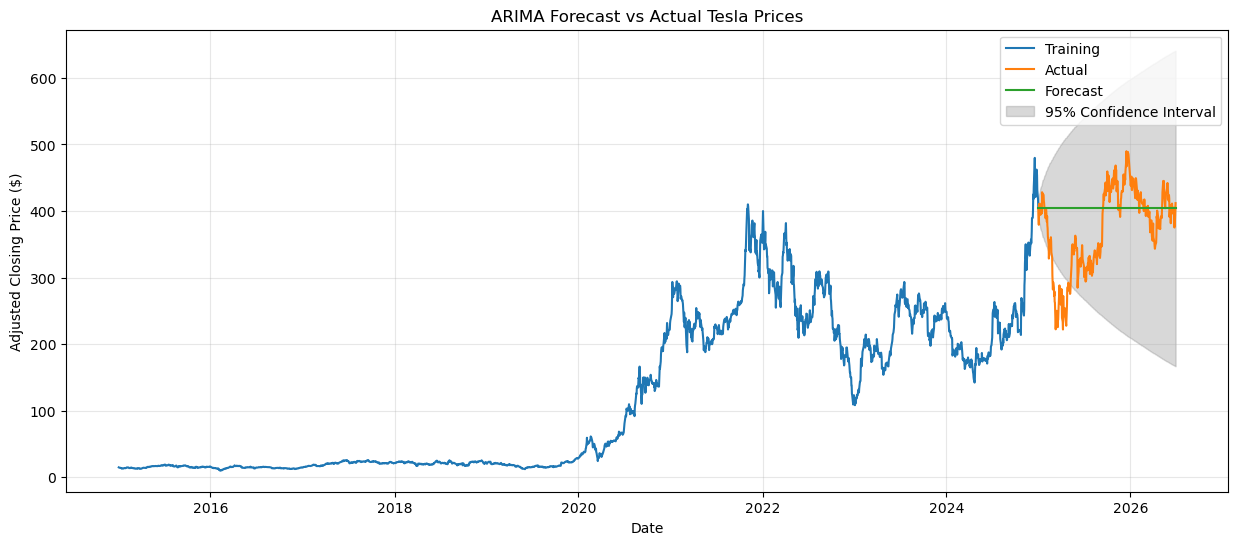

In [14]:
plt.figure(figsize=(15,6))

plt.plot(train, label="Training")
plt.plot(test, label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.fill_between(
    test.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    color="gray",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("ARIMA Forecast vs Actual Tesla Prices")

plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price ($)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Evaluate the ARIMA Model

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

#mae = mean_absolute_error(test, forecast)

#rmse = np.sqrt(mean_squared_error(test, forecast))

#mape = mean_absolute_percentage_error(test, forecast)

metrics = evaluate(
    test,
    forecast_values
)

print(metrics)


#print(f"MAE : {mae:.4f}")
#print(f"RMSE: {rmse:.4f}")
#print(f"MAPE: {mape:.4%}")

{'MAE': 54.29522741895578, 'RMSE': 70.44472587902374, 'MAPE': 17.19443181956443}


### ARIMA Model Evaluation Summary

The ARIMA model achieved an MAE of 54.44, an RMSE of 70.54, and a MAPE of 17.24%. These results indicate that the model captures the general price level but struggles to follow Tesla's rapid price fluctuations. This behaviour is expected because the selected ARIMA(0,1,0) model represents a random walk, where future prices are assumed to be close to the most recent observed price. These metrics will serve as the baseline for comparison with the LSTM model.

# Long Short-Term Memory (LSTM) Model

Unlike ARIMA, which is a statistical forecasting model, Long Short-Term Memory (LSTM) is a deep learning model designed to learn complex temporal patterns in sequential data. LSTM networks are capable of remembering long-term dependencies and are widely used for financial time series forecasting.

In [17]:
import sys

%pip install tensorflow --no-cache-dir --default-timeout=1000

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

from sklearn.preprocessing import MinMaxScaler

Note: you may need to restart the kernel to use updated packages.


In [18]:
import tensorflow as tf

print(tf.__version__)

2.16.2


In [19]:
tsla = prices["TSLA"]
train = tsla[:'2024-12-31']
test = tsla['2025-01-01':]

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 2516
Testing samples: 372


In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

test_scaled = scaler.transform(test.values.reshape(-1, 1))

In [21]:
X_train = []
y_train = []

window_size = 60

for i in range(window_size, len(train_scaled)):
    
    X_train.append(train_scaled[i-window_size:i, 0])
    
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

In [22]:
print(X_train.shape)
print(y_train.shape)

(2456, 60)
(2456,)


In [23]:
X_train = np.reshape(
    X_train,
    (X_train.shape[0],
     X_train.shape[1],
     1)
)

print(X_train.shape)

(2456, 60, 1)


In [24]:
print(X_train.shape)
print(y_train.shape)

(2456, 60, 1)
(2456,)


Building the LSTM Network

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()


model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=64,
        return_sequences=False
    )
)

model.add(Dropout(0.2))


model.add(Dense(25))
model.add(Dense(1))

Compile the Model

In [26]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

View the Model

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

Train the LSTM Model

In [28]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - loss: 0.0287 - val_loss: 0.0025
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - loss: 0.0014 - val_loss: 0.0026
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - loss: 0.0012 - val_loss: 0.0050
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - loss: 0.0010 - val_loss: 0.0021
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - loss: 8.7564e-04 - val_loss: 0.0019
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 7.8258e-04 - val_loss: 0.0025
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 92m

Plot Training History

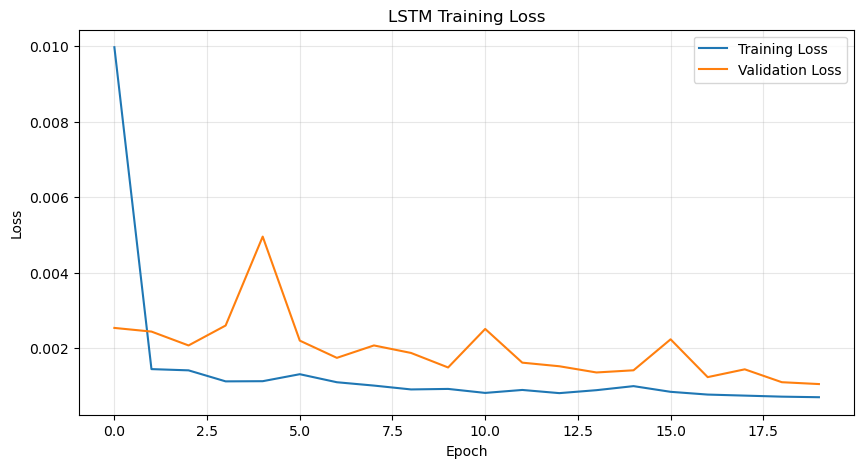

In [29]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Prepare Test Sequences

In [30]:
total_data = pd.concat((train, test), axis=0)

inputs = total_data[len(total_data) - len(test) - 60:]

inputs = scaler.transform(inputs.values.reshape(-1,1))

Build Test Windows

In [31]:
X_test = []

for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)

X_test = np.reshape(
    X_test,
    (X_test.shape[0], X_test.shape[1], 1)
)

print(X_test.shape)

(372, 60, 1)


Generate Predictions

In [32]:
predictions = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step


Convert Back to Real Prices

In [33]:
predictions = scaler.inverse_transform(predictions)

Evaluate the LSTM

In [34]:
lstm_mae = mean_absolute_error(
    test,
    predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        test,
        predictions
    )
)

lstm_mape = mean_absolute_percentage_error(
    test,
    predictions
)

print(f"MAE : {lstm_mae:.4f}")
print(f"RMSE: {lstm_rmse:.4f}")
print(f"MAPE: {lstm_mape*100:.4f}%")

MAE : 14.2835
RMSE: 18.1551
MAPE: 3.9389%


Visualize Predictions

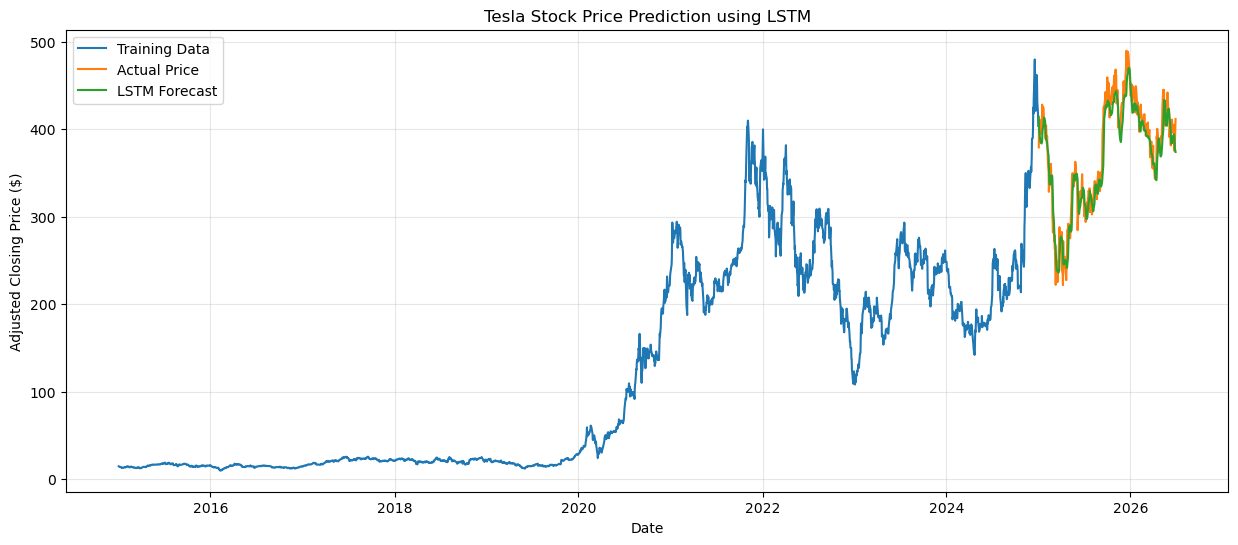

In [35]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual Price"
)

plt.plot(
    test.index,
    predictions,
    label="LSTM Forecast"
)

plt.title("Tesla Stock Price Prediction using LSTM")

plt.xlabel("Date")

plt.ylabel("Adjusted Closing Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [36]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


In [38]:
comparison = pd.DataFrame({

    "Model": ["ARIMA", "LSTM"],

    "MAE": [
        54.2952,
        14.2835
    ],

    "RMSE": [
        70.4447,
        18.1551
    ],

    "MAPE (%)": [
        17.1944,
        3.9389
    ]
})

comparison

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,54.2952,70.4447,17.1944
1,LSTM,14.2835,18.1551,3.9389


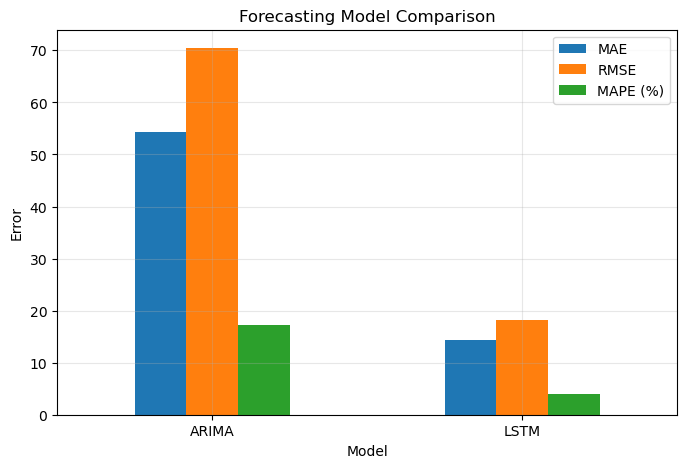

In [39]:
comparison.set_index("Model")[["MAE","RMSE","MAPE (%)"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Forecasting Model Comparison")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.grid(alpha=0.3)

plt.show()

Two forecasting models were developed to predict Tesla's adjusted closing prices: a classical ARIMA model and a deep learning LSTM model. Model performance was evaluated using MAE, RMSE, and MAPE.

The LSTM model consistently outperformed the ARIMA model across all evaluation metrics. Its MAE decreased from 54.29 to 14.28, while RMSE dropped from 70.44 to 18.16. Similarly, the forecasting error measured by MAPE decreased from 17.19% to 3.94%.

These results indicate that the LSTM model captured Tesla's highly nonlinear and volatile price movements much more effectively than the ARIMA model. In contrast, ARIMA assumes primarily linear relationships and therefore struggled to model Tesla's rapid fluctuations, producing forecasts that were relatively flat.

Based on these results, the LSTM model is selected as the preferred forecasting approach for Tesla stock price prediction.

In [40]:
model.save("../models/lstm_model.keras")

In [41]:
import pickle

with open("../models/arima_model.pkl", "wb") as f:
    pickle.dump(arima_fit, f)

Task 3 

In [42]:
from pandas.tseries.offsets import BDay

In [43]:
future_days = 252

In [44]:
last_sequence = scaler.transform(
    tsla.values.reshape(-1,1)
)[-60:]

Make Future Forecasts

In [45]:
future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    pred = model.predict(
        current_sequence.reshape(1,60,1),
        verbose=0
    )

    future_predictions.append(pred[0,0])

    current_sequence = np.append(
        current_sequence[1:],
        pred
    ).reshape(-1,1)

Convert Back

In [46]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

Create Future Dates

In [47]:
future_dates = pd.date_range(
    start=tsla.index[-1] + BDay(1),
    periods=future_days,
    freq="B"
)

future_dates[:5]

DatetimeIndex(['2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03',
               '2026-07-06'],
              dtype='datetime64[ns]', freq='B')

Convert Predictions into a DataFrame

In [48]:
future_forecast = pd.DataFrame(
    future_predictions,
    index=future_dates,
    columns=["Forecast"]
)

future_forecast.head()

,Forecast
2026-06-30,377.142334
2026-07-01,377.222748
2026-07-02,376.032257
2026-07-03,374.145813
2026-07-06,371.898865


Create Approximate Confidence Intervals

In [49]:
rmse = 18.1551

future_forecast["Lower"] = (
    future_forecast["Forecast"] - 1.96 * rmse
)

future_forecast["Upper"] = (
    future_forecast["Forecast"] + 1.96 * rmse
)

Plot Historical Prices and Future Forecast

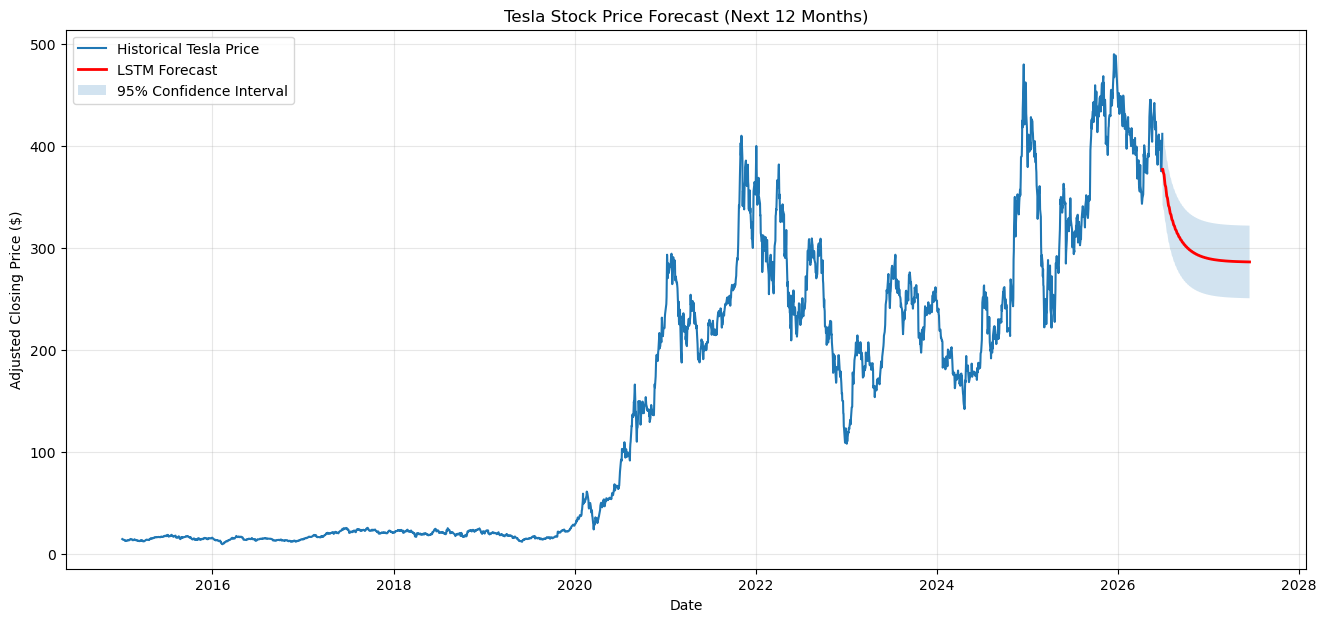

In [50]:
plt.figure(figsize=(16,7))

plt.plot(
    tsla,
    label="Historical Tesla Price"
)

plt.plot(
    future_forecast.index,
    future_forecast["Forecast"],
    color="red",
    linewidth=2,
    label="LSTM Forecast"
)

plt.fill_between(
    future_forecast.index,
    future_forecast["Lower"],
    future_forecast["Upper"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("Tesla Stock Price Forecast (Next 12 Months)")

plt.xlabel("Date")

plt.ylabel("Adjusted Closing Price ($)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

1. Trend Analysis 

The LSTM model forecasts a downward trend in Tesla's adjusted closing price over the next 12 months. Following the final historical observation, the forecast shows a relatively steep decline before gradually stabilizing around a lower price level. This suggests that the model expects the strong price fluctuations observed in recent years to moderate over the forecast horizon. No major upward reversal is predicted during the forecast period, indicating a cautious outlook for Tesla's future stock performance.

The forecast follows a smooth trajectory because each predicted value is used as input for the next prediction. As forecasting extends further into the future, prediction errors accumulate, causing the model to become less responsive to sudden market movements.

2. Opportunities and Risks 

- Investors may identify attractive entry points if Tesla's price declines before recovering.
- A more stable price trend could reduce short-term market volatility.
- Long-term investors may benefit if the forecasted decline is temporary and market fundamentals remain strong.

Risks

- The forecast indicates a potential decline in Tesla's stock price over the next year.
- Tesla remains a highly volatile growth stock whose price is sensitive to economic conditions, competition, and company-specific news.
- Unexpected market events may cause actual prices to differ significantly from the forecast.


Forecast Reliability

In [51]:
uncertainty = np.linspace(
    rmse,
    rmse * 2,
    future_days
)

future_forecast["Lower"] = (
    future_forecast["Forecast"] - 1.96 * uncertainty
)

future_forecast["Upper"] = (
    future_forecast["Forecast"] + 1.96 * uncertainty
)

Forecast Reliability 

The confidence interval becomes progressively wider as the forecast moves further into the future. This reflects increasing uncertainty in long-term predictions, since small prediction errors accumulate over time. Consequently, the short-term forecasts are expected to be more reliable than those generated for later months. While the LSTM model captures the overall trend effectively, its long-term forecasts should be interpreted as probable scenarios rather than exact future prices.

LSTM-based forecast of Tesla's adjusted closing price for the next 12 months with 95% confidence intervals. The model predicts a gradual decline followed by stabilization, while the widening confidence interval illustrates increasing uncertainty over longer forecasting horizons.

In [52]:
future_forecast = pd.DataFrame(
    future_predictions,
    columns=["Forecasted_Price"]
)

future_forecast.to_csv(
    "../data/processed/tsla_future_forecast.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.
